# 06: Batch Effects via Simple Features

Extract **mean, std, min, max** per channel → 28 features

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("/baldig/bioprojects2/emartinl/chemores/preprocessed_phasor")
RESULTS_DIR = Path("/home/emartinl/chemores/results")
RESULTS_DIR.mkdir(exist_ok=True)

## 8 Files

In [3]:
FILE_INFO = [
    ("CNTL-MB231", "Control"),
    ("TAMO-MB231", "Chemoresistant"),
    ("CNTL_75uM_p1", "Control"),
    ("CNTL_75uM_p2", "Control"),
    ("CNTL_75uM_p3", "Control"),
    ("CNTL_75uM_p4", "Control"),
    ("TAMO_p1", "Chemoresistant"),
    ("TAMO_p2", "Chemoresistant"),
]
print(f"Files to analyze: {len(FILE_INFO)}")

Files to analyze: 8


## Vectorized Feature Extraction

In [5]:
def extract_batch_features(images):
    """
    Ultra-fast vectorized extraction.
    Works with numpy arrays AND memory-mapped arrays.
    images: shape (N, C, H, W)
    returns: (N, 4*C) = mean/std/min/max per channel
    """
    N, C = images.shape[0], images.shape[1]
    H, W = images.shape[2], images.shape[3]
    
    # Process directly without creating intermediate arrays
    reshaped = images.reshape(N, C, H*W)
    
    means = np.mean(reshaped, axis=2)
    stds = np.std(reshaped, axis=2)
    mins = np.min(reshaped, axis=2)
    maxs = np.max(reshaped, axis=2)
    
    return np.column_stack([means, stds, mins, maxs])

# Test
test_file = DATA_DIR / "CNTL-MB231_cells.npy"
test_data = np.load(test_file, mmap_mode="r")
test_batch = np.array([test_data[0], test_data[1], test_data[2]])
test_features = extract_batch_features(test_batch)
print(f"Test: {test_features.shape}")

Test: (3, 28)


## Load & Extract All Files

In [ ]:
print("Extracting features...")
import time
all_features = []
all_files = []
all_classes = []

n_per_file = 60
start_total = time.time()

for i, (file_name, class_label) in enumerate(FILE_INFO, 1):
    print(f"\n[{i}/8] {file_name} ({class_label})")
    
    # Load metadata
    t0 = time.time()
    meta = pd.read_csv(DATA_DIR / f"{file_name}_cells_meta.csv")
    print(f"  → Loaded metadata ({len(meta)} cells) in {time.time()-t0:.1f}s")
    
    # Load images (mmap)
    t0 = time.time()
    images_full = np.load(DATA_DIR / f"{file_name}_cells.npy", mmap_mode="r")
    print(f"  → Memory-mapped images {images_full.shape} in {time.time()-t0:.1f}s")
    
    # Sample indices
    t0 = time.time()
    idx = np.random.choice(len(meta), min(n_per_file, len(meta)), replace=False)
    print(f"  → Sampled {len(idx)} indices in {time.time()-t0:.1f}s")
    
    # Extract features (process in small batches to balance speed & memory)
    t0 = time.time()
    batch_size = 15
    file_features = []
    for batch_start in range(0, len(idx), batch_size):
        batch_end = min(batch_start + batch_size, len(idx))
        batch_idx = idx[batch_start:batch_end]
        
        # Load small batch
        batch_imgs = np.array([images_full[i] for i in batch_idx])
        batch_feats = extract_batch_features(batch_imgs)
        file_features.extend(batch_feats)
        
        print(f"    ... processed {batch_end}/{len(idx)} images ({batch_size} per batch)")
    
    features = np.array(file_features)
    print(f"  → Extracted {features.shape} features in {time.time()-t0:.1f}s")
    
    all_features.append(features)
    all_files.extend([file_name] * len(features))
    all_classes.extend([class_label] * len(features))

elapsed = time.time() - start_total
X = np.vstack(all_features)
y_file = np.array(all_files)
y_class = np.array(all_classes)

print(f"\n✓ Total: {X.shape[0]} cells × {X.shape[1]} features")
print(f"✓ Time: {elapsed:.1f}s")

Extracting features...

[1/8] CNTL-MB231 (Control)
  → Loaded metadata (4500 cells) in 2.5s
  → Memory-mapped images (4500, 7, 512, 512) in 0.0s
  → Sampled 60 indices in 0.0s
    ... processed 15/60 images (15 per batch)
    ... processed 30/60 images (15 per batch)
    ... processed 45/60 images (15 per batch)
    ... processed 60/60 images (15 per batch)
  → Extracted (60, 28) features in 177.7s

[2/8] TAMO-MB231 (Chemoresistant)
  → Loaded metadata (5750 cells) in 0.1s
  → Memory-mapped images (5750, 7, 512, 512) in 0.1s
  → Sampled 60 indices in 0.0s
    ... processed 15/60 images (15 per batch)
    ... processed 30/60 images (15 per batch)
    ... processed 45/60 images (15 per batch)
    ... processed 60/60 images (15 per batch)
  → Extracted (60, 28) features in 221.6s

[3/8] CNTL_75uM_p1 (Control)
  → Loaded metadata (6012 cells) in 0.1s
  → Memory-mapped images (6012, 7, 512, 512) in 0.1s
  → Sampled 60 indices in 0.0s
    ... processed 15/60 images (15 per batch)
    ... pro

## Normalize

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"✓ Scaled: mean={X_scaled.mean():.6f}, std={X_scaled.std():.6f}")

✓ Scaled: mean=-0.000000, std=0.866025


## PCA

In [ ]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)
print(f"✓ PCA: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

✓ PCA: PC1=65.1%, PC2=9.9%


## Plot PCA

✓ Saved: features_pca.png


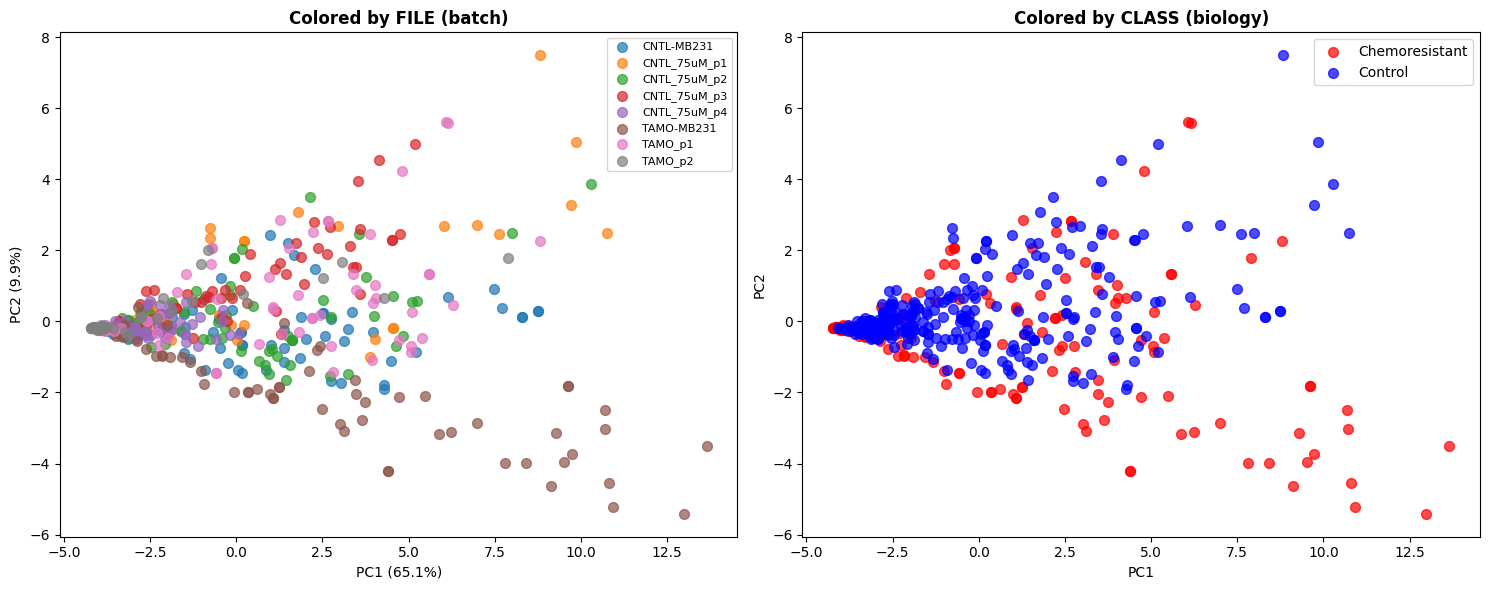

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By FILE
ax = axes[0]
colors_file = plt.cm.tab10(np.arange(len(FILE_INFO)))
file_to_color = {name: colors_file[i] for i, (name, _) in enumerate(FILE_INFO)}
for file_name in np.unique(y_file):
    mask = y_file == file_name
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=file_name, s=50, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Colored by FILE (batch)", fontweight="bold")
ax.legend(fontsize=8)

# By CLASS
ax = axes[1]
colors_class = {"Control": "blue", "Chemoresistant": "red"}
for class_label in np.unique(y_class):
    mask = y_class == class_label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=class_label, s=50, alpha=0.7, c=colors_class[class_label])
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.set_title("Colored by CLASS (biology)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "features_pca.png", dpi=150)
print("✓ Saved: features_pca.png")
plt.show()

## tSNE

In [ ]:
print("Computing tSNE...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=500, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca)
print("✓ Done")

Computing tSNE...
✓ Done


## Plot tSNE

✓ Saved: features_tsne.png


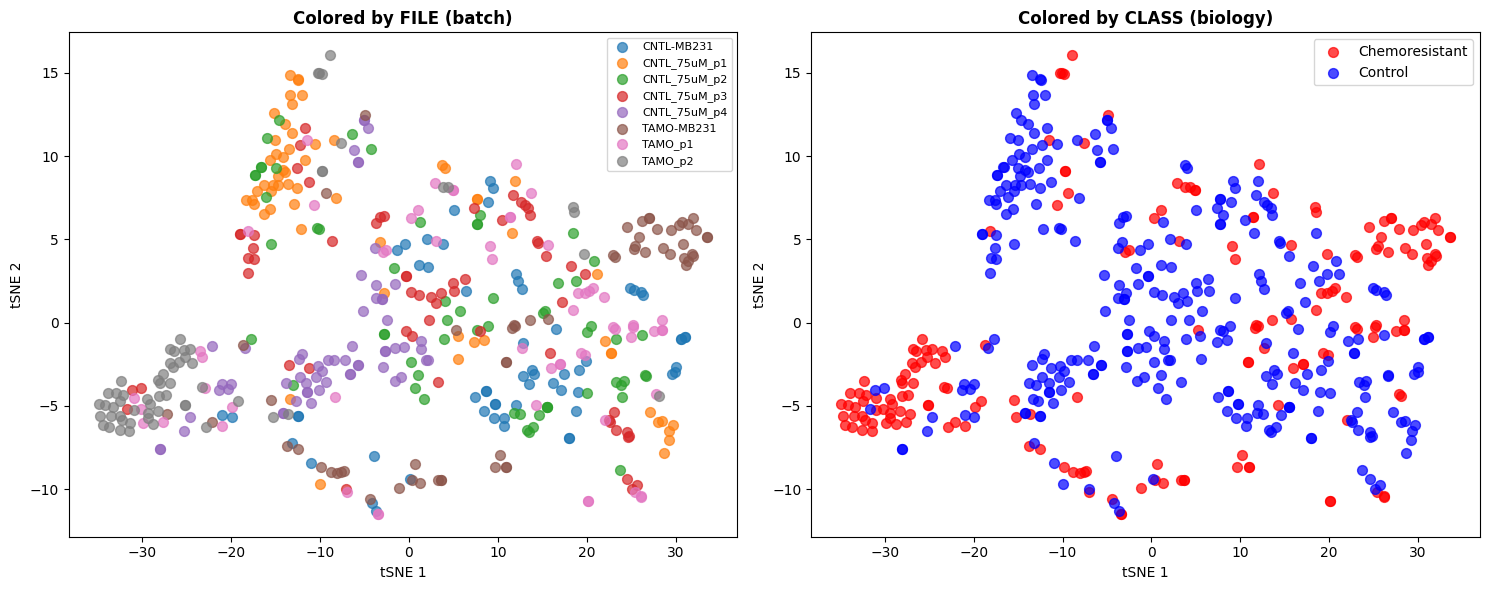

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# By FILE
ax = axes[0]
for file_name in np.unique(y_file):
    mask = y_file == file_name
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=file_name, s=50, alpha=0.7)
ax.set_xlabel("tSNE 1")
ax.set_ylabel("tSNE 2")
ax.set_title("Colored by FILE (batch)", fontweight="bold")
ax.legend(fontsize=8)

# By CLASS
ax = axes[1]
for class_label in np.unique(y_class):
    mask = y_class == class_label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=class_label, s=50, alpha=0.7, c=colors_class[class_label])
ax.set_xlabel("tSNE 1")
ax.set_ylabel("tSNE 2")
ax.set_title("Colored by CLASS (biology)", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "features_tsne.png", dpi=150)
print("✓ Saved: features_tsne.png")
plt.show()